In [1]:
import polars as pl
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
conversation_results_multiple_runs_per_model = pl.read_csv(
    "healthbench_granular_data_20251120.tsv", separator="\t"
)
conversation_results_multiple_runs_per_model.head()

model,run_id,conversation_id,rubric_criterion_index,axis,points,criterion_met,theme
str,str,str,i64,str,i64,bool,str
"""llama-4-maverick""","""20251027_153644""","""1f548d5b-cd00-49a0-b327-283a2e…",0,"""completeness""",10,true,"""context_seeking"""
"""llama-4-maverick""","""20251027_153644""","""1f548d5b-cd00-49a0-b327-283a2e…",1,"""completeness""",9,false,"""context_seeking"""
"""llama-4-maverick""","""20251027_153644""","""1f548d5b-cd00-49a0-b327-283a2e…",2,"""context_awareness""",7,false,"""context_seeking"""
"""llama-4-maverick""","""20251027_153644""","""1f548d5b-cd00-49a0-b327-283a2e…",3,"""accuracy""",-10,false,"""context_seeking"""
"""llama-4-maverick""","""20251027_153644""","""1f548d5b-cd00-49a0-b327-283a2e…",4,"""completeness""",8,true,"""context_seeking"""


In [3]:
# Old approach

# Let's keep just one run from the models that ran multiple times. We will do
# that by dropping all rows for a given model that don't have a particular
# run_id. If a model doesn't show up in this list it's because it only had one
# run to begin with

# runs_to_keep = [
#     ("llama-3.3-70b", "20251029_012947"),
#     ("llama-4-maverick", "20251027_165626"),
#     ("llama-4-scout", "20251027_091851"),
# ]
# conversation_results = conversation_results_multiple_runs_per_model
# for model_name, run_id in runs_to_keep:
#     conversation_results = conversation_results.filter(
#         (pl.col("model") != model_name)
#         | ((pl.col("model") == model_name) & (pl.col("run_id") == run_id))
#     )

In [4]:
# Jason's approach


def filter_to_first_run(group: pl.DataFrame) -> pl.DataFrame:
    first_run = group["run_id"].min()
    assert first_run is not None
    return group.filter(pl.col("run_id") == first_run)


conversation_results = conversation_results_multiple_runs_per_model.group_by(
    "model"
).map_groups(filter_to_first_run)

# Check that the filtering worked correctly - we should see one run per model
unique_model_runs = (
    conversation_results.select("model", "run_id").unique().sort("model")
)
assert len(unique_model_runs) == len(
    conversation_results_multiple_runs_per_model.select("model").unique()
)

In [5]:
def get_mean_and_confidence_intervals(scores: pl.Series) -> dict:
    scores_np = scores.to_numpy()
    mean = np.clip(np.mean(scores_np), 0, 1).item()
    lower, upper = np.percentile(
        [np.mean(np.random.choice(scores_np, len(scores_np))) for _ in range(1000)],
        [2.5, 97.5],
    )
    return {"mean": mean, "lower_ci": float(lower), "upper_ci": float(upper)}

In [6]:
theme_results = (
    conversation_results.vstack(
        # Add another copy of the DF where all conversations are duplicated
        # under the "all" theme, in order to calculate the overall score and CIs
        conversation_results.with_columns(pl.lit("all").alias("theme"))
    )
    .with_columns(
        # Determine whether the points should actually be awarded for each criterion
        pl.when("criterion_met")
        .then("points")
        .otherwise(pl.lit(0))
        .alias("criterion_points_awarded"),
    )
    .group_by("model", "run_id", "theme", "conversation_id")
    .agg(
        # Calculate the total number of points possible for the conversation
        pl.col("points")
        .filter(pl.col("points") > 0)
        .sum()
        .alias("conversation_points_possible"),
        # Sum the points awarded for this conversation, note that the score for an
        # individual conversation can be negative, but the overall/theme/axis score
        # is clipped to a minimum of 0
        pl.col("criterion_points_awarded").sum().alias("conversation_points_awarded"),
    )
    .with_columns(
        # Calculate the score for each conversation
        (
            pl.col("conversation_points_awarded")
            / pl.col("conversation_points_possible")
        ).alias("conversation_score")
    )
    .group_by("model", "run_id", "theme")
    .agg(
        # Calculate a mean with CI at the run level
        pl.col("conversation_score")
        .map_batches(function=get_mean_and_confidence_intervals, returns_scalar=True)
        .alias("results_struct"),
        pl.col("model").count().alias("n"),
    )
    .unnest("results_struct")
)

In [7]:
axis_results = (
    conversation_results.vstack(
        # Add another copy of the DF where all conversations a duplicated under the
        # "all" theme, in order to calculate the overall score and CI
        conversation_results.with_columns(pl.lit("all").alias("axis"))
    )
    .with_columns(
        # Determine whether the points should actually be awarded for each criterion
        pl.when("criterion_met")
        .then("points")
        .otherwise(pl.lit(0))
        .alias("criterion_points_awarded"),
    )
    .group_by("model", "run_id", "axis", "conversation_id")
    .agg(
        # Calculate the total number of points possible for the conversation
        pl.col("points")
        .filter(pl.col("points") > 0)
        .sum()
        .alias("conversation_points_possible"),
        # Sum the points awarded for this quesiton, note that the score for an
        # individual question can be negative, but the overall/theme/axis score
        # is clipped to a minimum of 0
        pl.col("criterion_points_awarded").sum().alias("conversation_points_awarded"),
    )
    # Filter out questions that do not have any criteria for a given axis
    .filter(pl.col("conversation_points_possible") > 0)
    .with_columns(
        # Calculate the score for each conversation
        (
            pl.col("conversation_points_awarded")
            / pl.col("conversation_points_possible")
        ).alias("conversation_score")
    )
    .group_by("model", "run_id", "axis")
    .agg(
        # Calculate a mean with CI at the run level
        pl.col("conversation_score")
        .map_batches(function=get_mean_and_confidence_intervals, returns_scalar=True)
        .alias("results_struct")
    )
    .unnest("results_struct")
)

In [8]:
axis_results.select("axis").unique()

axis
str
"""context_awareness"""
"""instruction_following"""
"""accuracy"""
"""all"""
"""communication_quality"""
"""completeness"""


In [9]:
sns.set_style("whitegrid")

(0.0, 0.65)

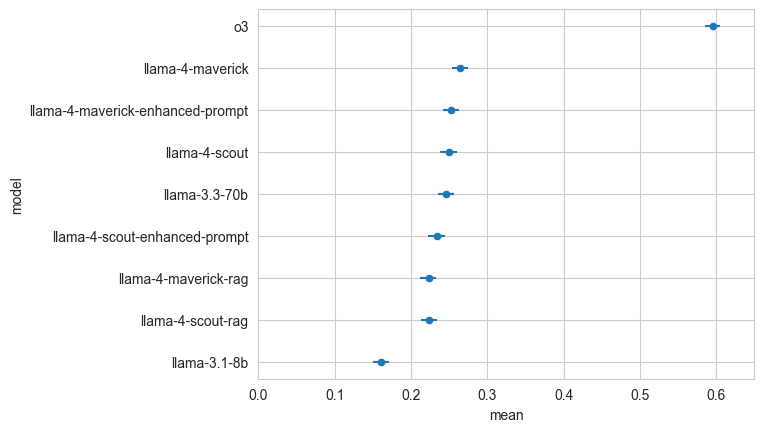

In [10]:
# Plot overall results
overall_results = theme_results.filter(pl.col("theme") == "all").sort(
    "mean", descending=True
)
g = sns.scatterplot(data=overall_results, x="mean", y="model")
plt.hlines(
    overall_results["model"], overall_results["lower_ci"], overall_results["upper_ci"]
)
g.set_xlim(0, 0.65)

(0.0, 0.65)

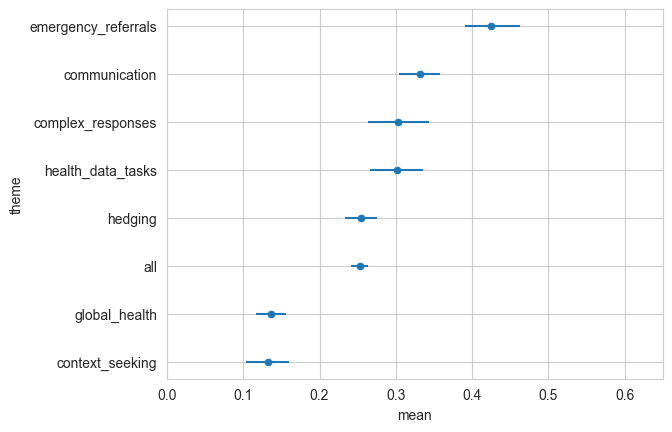

In [11]:
# Plot theme results
plot_df = theme_results.filter(
    pl.col("model") == "llama-4-maverick-enhanced-prompt"
).sort("mean", descending=True)
g = sns.scatterplot(data=plot_df, x="mean", y="theme")
plt.hlines(plot_df["theme"], plot_df["lower_ci"], plot_df["upper_ci"])
g.set_xlim(0, 0.65)

## Plot Results Relative to a Baseline

In [12]:
unique_model_runs

model,run_id
str,str
"""llama-3.1-8b""","""20251030_123814"""
"""llama-3.3-70b""","""20251028_162900"""
"""llama-4-maverick""","""20251023_212754"""
"""llama-4-maverick-enhanced-prom…","""20251119_223124"""
"""llama-4-maverick-rag""","""20251118_161039"""
"""llama-4-scout""","""20251023_153707"""
"""llama-4-scout-enhanced-prompt""","""20251119_213733"""
"""llama-4-scout-rag""","""20251118_204328"""
"""o3""","""20251029_151631"""


In [13]:
model_baseline_map = {
    "llama-3.1-8b": [],
    "llama-3.3-70b": [],
    "llama-4-maverick": ["llama-4-maverick-rag", "llama-4-maverick-enhanced-prompt"],
    "llama-4-scout": ["llama-4-scout-rag", "llama-4-scout-enhanced-prompt"],
    "o3": [],
}

In [14]:
# Calculate theme performance for maverick relative to the baseline
baseline_model = "llama-4-maverick"


def subtract_baseline_mean(s: pl.DataFrame) -> pl.DataFrame:
    """
    Subtracts the baseline mean from the non-baseline means, and confidence
    limits.
    """
    baseline = s.filter(pl.col("model") == baseline_model)
    rest = s.filter(pl.col("model") != baseline_model)
    return rest.with_columns(
        (pl.col("mean") - baseline["mean"].item()).alias("relative_mean"),
        (pl.col("lower_ci") - baseline["mean"].item()).alias("relative_lower_ci"),
        (pl.col("upper_ci") - baseline["mean"].item()).alias("relative_upper_ci"),
    )


iteration_models = model_baseline_map[baseline_model]
relative_theme_performance = (
    theme_results.filter(
        # Filter the dataframe down to only the baseline model and its later
        # iterations
        (pl.col("model") == baseline_model) | pl.col("model").is_in(iteration_models)
    )
    .group_by("theme")
    .map_groups(subtract_baseline_mean)
    .sort("theme", "model")
)
relative_axis_performance = (
    axis_results.filter(
        (pl.col("model") == baseline_model) | pl.col("model").is_in(iteration_models)
    )
    .group_by("axis")
    .map_groups(subtract_baseline_mean)
    .sort("axis", "model")
)

relative_axis_performance

model,run_id,axis,mean,lower_ci,upper_ci,relative_mean,relative_lower_ci,relative_upper_ci
str,str,str,f64,f64,f64,f64,f64,f64
"""llama-4-maverick-enhanced-prom…","""20251119_223124""","""accuracy""",0.406297,0.391617,0.421013,-0.010564,-0.025244,0.004152
"""llama-4-maverick-rag""","""20251118_161039""","""accuracy""",0.400023,0.385701,0.414219,-0.016838,-0.03116,-0.002642
"""llama-4-maverick-enhanced-prom…","""20251119_223124""","""all""",0.252568,0.242181,0.262881,-0.011877,-0.022265,-0.001565
"""llama-4-maverick-rag""","""20251118_161039""","""all""",0.223284,0.212428,0.234253,-0.041162,-0.052017,-0.030193
"""llama-4-maverick-enhanced-prom…","""20251119_223124""","""communication_quality""",0.676162,0.652744,0.697969,-0.00809,-0.031508,0.013717
…,…,…,…,…,…,…,…,…
"""llama-4-maverick-rag""","""20251118_161039""","""completeness""",0.026831,0.00989,0.043876,-0.074389,-0.09133,-0.057345
"""llama-4-maverick-enhanced-prom…","""20251119_223124""","""context_awareness""",0.281973,0.259988,0.304974,0.014573,-0.007412,0.037573
"""llama-4-maverick-rag""","""20251118_161039""","""context_awareness""",0.241192,0.220331,0.261976,-0.026209,-0.04707,-0.005424


Text(0.5, 1.0, 'Themes - llama-4-maverick-enhanced-prompt')

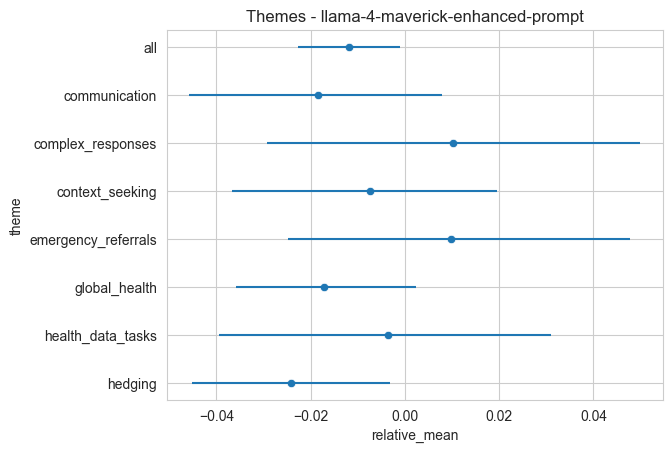

In [15]:
# Plot theme results relative to the baseline mean
target_model = "llama-4-maverick-enhanced-prompt"
plot_df = relative_theme_performance.filter(pl.col("model") == target_model)
g = sns.scatterplot(
    data=plot_df,
    x="relative_mean",
    y="theme",
)
plt.hlines(
    plot_df["theme"],
    plot_df["relative_lower_ci"],
    plot_df["relative_upper_ci"],
)
g.set_title(f"Themes - {target_model}")

Text(0.5, 1.0, 'Axes - llama-4-maverick-enhanced-prompt')

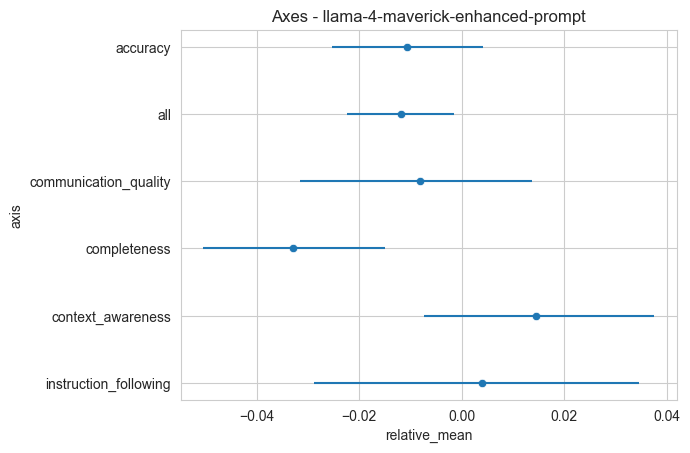

In [16]:
# Plot axis results relative to the baseline mean
taget_model = "llama-4-maverick-enhanced-prompt"

plot_df = relative_axis_performance.filter(pl.col("model") == target_model)
g = sns.scatterplot(data=plot_df, x="relative_mean", y="axis")
plt.hlines(
    plot_df["axis"],
    plot_df["relative_lower_ci"],
    plot_df["relative_upper_ci"],
)
g.set_title(f"Axes - {target_model}")

In [17]:
theme_results.filter(pl.col("theme") == "health_data_tasks").sort(
    "mean", descending=True
)

model,run_id,theme,mean,lower_ci,upper_ci,n
str,str,str,f64,f64,f64,u32
"""o3""","""20251029_151631""","""health_data_tasks""",0.450835,0.407825,0.490932,477
"""llama-4-maverick""","""20251023_212754""","""health_data_tasks""",0.305237,0.265812,0.34316,477
"""llama-4-maverick-enhanced-prom…","""20251119_223124""","""health_data_tasks""",0.301584,0.26572,0.336188,477
"""llama-4-scout""","""20251023_153707""","""health_data_tasks""",0.279137,0.243744,0.318804,477
"""llama-3.3-70b""","""20251028_162900""","""health_data_tasks""",0.274672,0.234125,0.312642,477
"""llama-4-scout-rag""","""20251118_204328""","""health_data_tasks""",0.271513,0.235901,0.30574,477
"""llama-4-scout-enhanced-prompt""","""20251119_213733""","""health_data_tasks""",0.270667,0.229921,0.30909,477
"""llama-4-maverick-rag""","""20251118_161039""","""health_data_tasks""",0.269336,0.230185,0.305637,477
"""llama-3.1-8b""","""20251030_123814""","""health_data_tasks""",0.186521,0.145768,0.222446,477
